In [5]:
# ==============================================================================
#                      1. 환경 설정 및 라이브러리 임포트
# ==============================================================================
# GPU 할당 확인
print("▼▼▼ GPU 정보 ▼▼▼")
!nvidia-smi

from google.colab import drive,files
drive.mount('/content/drive')
uploaded = files.upload()  # requirements.txt 업로드
!pip install -r requirements.txt

# 필요한 라이브러리 임포트
import json, os, glob, shutil, yaml, cv2, timm
import numpy as np, pandas as pd
from PIL import Image
from tqdm import tqdm
import matplotlib.pyplot as plt
import torch, torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import albumentations as A
from albumentations.pytorch import ToTensorV2
import torch.optim as optim
from torch.utils.data import WeightedRandomSampler

import random

def set_seed(seed=42):
    """결과 재현성을 위해 가능한 모든 랜덤 시드를 고정하는 함수"""
    random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)  # 여러 GPU를 사용하는 경우

    # CUDA 연산의 비결정성을 제어하여 재현성을 보장하는 가장 중요한 부분
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    print(f"Random seed set to {seed}")
    print("cuDNN set to deterministic mode. (Training may be slightly slower)")

# 시드 고정 함수 실행
set_seed(42)

▼▼▼ GPU 정보 ▼▼▼
Sat Oct 11 10:54:00 2025       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 550.54.15              Driver Version: 550.54.15      CUDA Version: 12.4     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA L4                      Off |   00000000:00:03.0 Off |                    0 |
| N/A   53C    P0             29W /   72W |   11797MiB /  23034MiB |      0%      Default |
|                                         |                        |                  N/A |
+--------------------------------

Saving requirements.txt to requirements (1).txt
Random seed set to 42
cuDNN set to deterministic mode. (Training may be slightly slower)


In [6]:
# ==============================================================================
#                         2. 데이터 준비 및 데이터셋 정의
# ==============================================================================


# --- 1. 원본 데이터 경로 설정 ---
# ★ 구글 드라이브 내에 압축 해제된 데이터 폴더의 상위 경로를 지정 (환경에 맞게 수정)
DRIVE_ROOT = '/content/drive/MyDrive/53.대기오염 배출원 공간 분포 데이터/3.개방데이터/1.데이터'

# 학습(Training) 및 검증(Validation) 데이터의 상세 경로를 정의
TRAIN_IMG_DIR_GDRIVE = os.path.join(DRIVE_ROOT, 'Training/01.원천데이터/TS_KS')
TRAIN_JSON_DIR_GDRIVE = os.path.join(DRIVE_ROOT, 'Training/02.라벨링데이터/TL_KS_LINE')
VAL_IMG_DIR_GDRIVE = os.path.join(DRIVE_ROOT, 'Validation/01.원천데이터/VS_KS')
VAL_JSON_DIR_GDRIVE = os.path.join(DRIVE_ROOT, 'Validation/02.라벨링데이터/VL_KS_LINE')

# --- 2. JSON 데이터 파싱 함수 정의 ---
def parse_line_json_to_df(gdrive_json_dir, gdrive_img_dir):
    """JSON을 파싱하여 (이미지 경로, bbox, 높이) 정보를 담은 DataFrame을 생성합니다."""
    print(f"Parsing JSON files from {gdrive_json_dir}...")
    json_files = glob.glob(os.path.join(gdrive_json_dir, '*.json'))
    all_data = []
    for json_path in tqdm(json_files, desc="Parsing JSON"):
        with open(json_path, 'r', encoding='utf-8') as f: data = json.load(f)
        data_key = list(data.keys())[0]; annotations = data[data_key]; filename = annotations['filename']
        img_path = os.path.join(gdrive_img_dir, filename)
        if os.path.exists(img_path):
            for region in annotations['regions']:
                points_x, points_y = region['shape_attributes']['all_points_x'], region['shape_attributes']['all_points_y']
                x_min, x_max = min(points_x), max(points_x); y_min, y_max = min(points_y), max(points_y)
                width, height = x_max - x_min, y_max - y_min
                padding_w, padding_h = width * 0.05 / 2, height * 0.05 / 2 # padding 0.05
                bbox = [max(0, x_min - padding_w), max(0, y_min - padding_h),
                        min(512, x_max + padding_w), min(512, y_max + padding_h)]
                height_val = float(region['region_attributes'].get('chi_height_m', 0.0))
                all_data.append([img_path, bbox, height_val])
    return pd.DataFrame(all_data, columns=['img_path', 'bbox', 'height'])

# 함수를 호출하여 Train/Validation DataFrame 생성
train_df = parse_line_json_to_df(TRAIN_JSON_DIR_GDRIVE, TRAIN_IMG_DIR_GDRIVE)
val_df = parse_line_json_to_df(VAL_JSON_DIR_GDRIVE, VAL_IMG_DIR_GDRIVE)
print(f"\nFinal training samples: {len(train_df)}")

# --- 3. 데이터 증강(Augmentation) 파이프라인 정의 ---
# 모델의 입력 이미지 크기 설정
IMG_SIZE = 224

# 학습(Train) 데이터에만 적용될 증강 기법들
train_transforms = A.Compose([
    # 모든 이미지를 동일한 크기(224x224)로 리사이즈
    A.Resize(height=IMG_SIZE, width=IMG_SIZE, interpolation=cv2.INTER_AREA),
    # 50% 확률로 좌우 반전
    A.HorizontalFlip(p=0.5),
    # -20 ~ +20도 범위 내에서 70% 확률로 회전 (형태 및 시점 왜곡 대응)
    A.Rotate(limit=20, p=0.7, border_mode=cv2.BORDER_CONSTANT, value=0),
    # ImageNet 통계치로 픽셀 값 정규화
    A.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    # PyTorch 텐서로 변환
    ToTensorV2()
])

# 검증(Validation) 데이터에는 최소한의 변환만 적용하여 일관된 평가 환경 보장
val_transforms = A.Compose([
    A.Resize(height=IMG_SIZE, width=IMG_SIZE, interpolation=cv2.INTER_AREA),
    A.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    ToTensorV2()
])

# --- 4. PyTorch Dataset 클래스 구현 ---
# '대칭적 학습' 전략: Train/Val 모두 Crop된 이미지를 사용
class SimpleCroppedChimneyDataset(Dataset):
    def __init__(self, dataframe, transform=None):
        self.df = dataframe; self.transform = transform
    def __len__(self): return len(self.df)
    def __getitem__(self, idx):
        # Bbox의 너비나 높이가 0 이하인 비정상적인 데이터를 안전하게 건너뛰는 로직
        while True:
            row = self.df.iloc[idx]; image_path, bbox, height = row['img_path'], row['bbox'], row['height']
            x_min, y_min, x_max, y_max = map(int, bbox)
            if x_min >= x_max or y_min >= y_max: idx = (idx + 1) % len(self.df); continue
            break
        # 원본 이미지 로드
        image = cv2.imread(image_path); image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        # Bbox 좌표를 이용해 굴뚝 부분만 잘라냄
        cropped_image = image[y_min:y_max, x_min:x_max]
        # 위에서 정의한 증강 파이프라인 적용
        if self.transform: image = self.transform(image=cropped_image)['image']
        return image, torch.tensor(height, dtype=torch.float32)

# --- 5. 데이터셋 인스턴스 생성 ---
train_dataset = SimpleCroppedChimneyDataset(train_df, transform=train_transforms)
val_dataset = SimpleCroppedChimneyDataset(val_df, transform=val_transforms)
print(f"Train/Val dataset size: {len(train_dataset)} / {len(val_dataset)}")

Parsing JSON files from /content/drive/MyDrive/53.대기오염 배출원 공간 분포 데이터/3.개방데이터/1.데이터/Training/02.라벨링데이터/TL_KS_LINE...


Parsing JSON: 100%|██████████| 8052/8052 [01:10<00:00, 114.34it/s]


Parsing JSON files from /content/drive/MyDrive/53.대기오염 배출원 공간 분포 데이터/3.개방데이터/1.데이터/Validation/02.라벨링데이터/VL_KS_LINE...


Parsing JSON: 100%|██████████| 1006/1006 [00:04<00:00, 203.20it/s]


Final training samples: 10590
Train/Val dataset size: 10590 / 1323



/tmp/ipython-input-3860145381.py:55: UserWarning: Argument(s) 'value' are not valid for transform Rotate
  A.Rotate(limit=20, p=0.7, border_mode=cv2.BORDER_CONSTANT, value=0),


In [7]:
# ==============================================================================
#                 3. 모델 아키텍처 정의 (EfficientNet-B3)
# ==============================================================================

# PyTorch의 nn.Module을 상속받아 커스텀 모델 클래스를 정의합니다.
class EffNetB3Estimator(nn.Module):
    def __init__(self, model_name='efficientnet_b3', pretrained=True):
        super().__init__()
        self.model = timm.create_model(model_name, pretrained=pretrained, num_classes=1)
        print(f"Model Initialized: {model_name} (pretrained={pretrained})")
    def forward(self, images):
        return self.model(images).squeeze(1)

Model Initialized: efficientnet_b3 (pretrained=True)
Device: cuda, Model:efficientnet_b3, Epochs: 100, Batch: 64, LR: 0.001


Epoch 1/100 [Train]: 100%|██████████| 166/166 [01:03<00:00,  2.62it/s]


Epoch 1/100 | Train RMSE: 28.6636 | Val RMSE: 20.2071 | LR: 0.001000
*** Best model saved (Val RMSE: 20.2071) ***


Epoch 2/100 [Train]: 100%|██████████| 166/166 [01:04<00:00,  2.58it/s]


Epoch 2/100 | Train RMSE: 17.1612 | Val RMSE: 15.4398 | LR: 0.000999
*** Best model saved (Val RMSE: 15.4398) ***


...

Epoch 98/100 | Train RMSE: 1.2982 | Val RMSE: 3.7287 | LR: 0.000001


Epoch 99/100 [Train]: 100%|██████████| 166/166 [01:04<00:00,  2.58it/s]


Epoch 99/100 | Train RMSE: 1.2152 | Val RMSE: 3.7307 | LR: 0.000000


Epoch 100/100 [Train]: 100%|██████████| 166/166 [01:04<00:00,  2.58it/s]


Epoch 100/100 | Train RMSE: 1.2738 | Val RMSE: 3.7234 | LR: 0.000000

--- Training Finished: Final Best Validation RMSE: 3.6200 ---


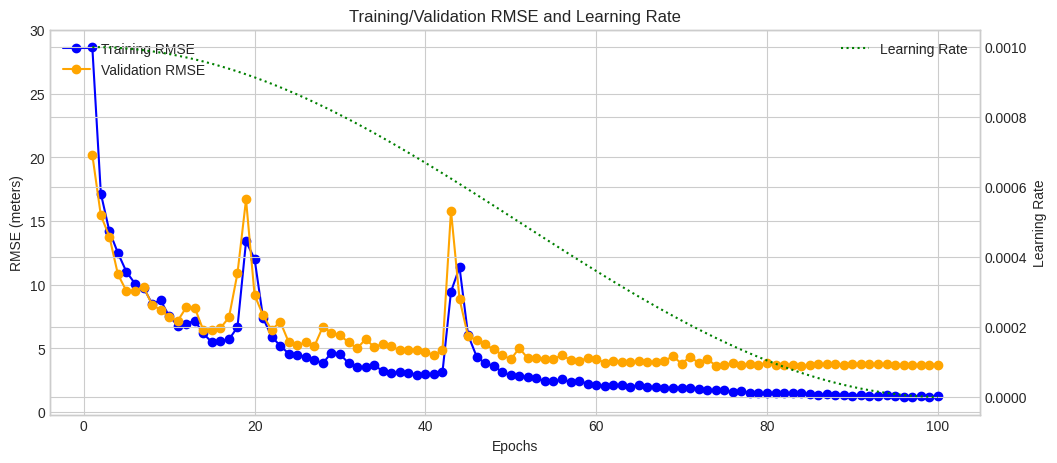

Final Prediction: 100%|██████████| 21/21 [00:06<00:00,  3.12it/s]


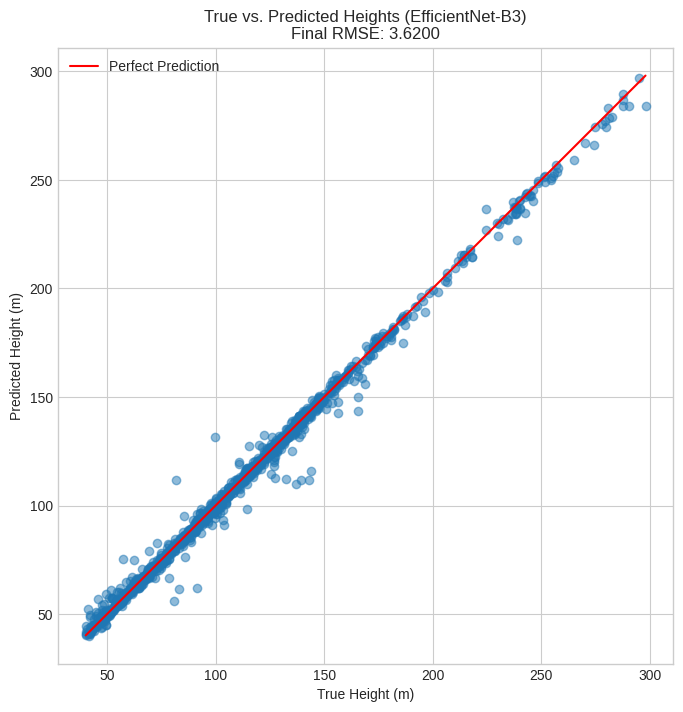

In [8]:
# ==============================================================================
#                      4. 학습 및 결과 분석
# ==============================================================================

# --- 1. 하이퍼파라미터 및 경로 설정 ---
# GPU 사용 여부를 자동으로 결정
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
# 한 번에 학습할 데이터의 양
BATCH_SIZE = 64
# 학습의 보폭을 결정하는 가장 중요한 파라미터
LEARNING_RATE = 1e-3
# 전체 데이터셋을 반복 학습할 횟수
EPOCHS = 100
# 과적합을 방지하기 위한 정규화 강도
WEIGHT_DECAY = 1e-3
# ★ 학습 결과가 저장될 경로 (환경에 맞게 수정)
PROJECT_SAVE_DIR = '/content/drive/MyDrive/DataCreatorCamp/Mission2_Results_EffNetB3_Final'
os.makedirs(PROJECT_SAVE_DIR, exist_ok=True)


# --- 2. 가중 샘플링(Weighted Sampling) 로직 ---
# 예측 오차가 집중되었던 50-200m 구간의 데이터 샘플에 더 높은 가중치를 부여
weights = []
for height in train_df['height']:
    if 50 <= height <= 200:
        weights.append(1.5)  # 문제 구간에 1.5배 높은 가중치 부여
    else:
        weights.append(1.0)  # 나머지 구간은 기본 가중치

# 각 데이터 샘플의 가중치를 기반으로 샘플러(Sampler)를 생성합니다.
# replacement=True: 한 에포크 내에서 동일한 샘플이 여러 번 뽑힐 수 있도록 허용
sampler = WeightedRandomSampler(weights, num_samples=len(weights), replacement=True)


# --- 3. 데이터로더 정의 ---
train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    sampler=sampler, # shuffle=True 대신, 위에서 정의한 가중 샘플러를 사용
    num_workers=2,   # 데이터 로딩을 위한 병렬 프로세스 수
    pin_memory=True  # GPU로 데이터를 더 빠르게 전송하기 위한 옵션
)
val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False, # 검증 시에는 순서대로 평가해야 하므로 shuffle=False
    num_workers=2,
    pin_memory=True
)


# --- 4. 모델, 손실함수, 옵티마이저, 스케줄러 정의 ---
# 모델: 셀 3에서 정의한 EfficientNet-B3 모델을 불러와 GPU로 이동
model = EffNetB3Estimator().to(DEVICE)
# 손실 함수: 회귀 문제의 표준적인 손실 함수인 MSE 사용
criterion = nn.MSELoss()
# AdamW를 사용하여 가중치를 업데이트
optimizer = optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
# CosineAnnealingLR을 사용하여 학습률을 점진적으로 감소시켜 안정적인 수렴 유도
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)

print(f"Device: {DEVICE}, Model:efficientnet_b3, Epochs: {EPOCHS}, Batch: {BATCH_SIZE}, LR: {LEARNING_RATE}")


# --- 5. 학습 및 검증 루프 ---
history = {'train_rmse': [], 'val_rmse': [], 'lr': []}
best_val_rmse = float('inf')

for epoch in range(EPOCHS):
    # --- 학습(Training) 단계 ---
    model.train(); train_loss = 0
    for images, heights in tqdm(train_loader, desc=f"Epoch {epoch+1}/{EPOCHS} [Train]"):
        images, heights = images.to(DEVICE), heights.to(DEVICE)
        optimizer.zero_grad(); preds = model(images); loss = criterion(preds, heights)
        loss.backward(); optimizer.step()
        train_loss += loss.item() * len(heights)
    # 현재 에포크의 평균 Train RMSE 계산 및 기록
    train_rmse = np.sqrt(train_loss / len(train_dataset)); history['train_rmse'].append(train_rmse)

    # --- 검증(Validation) 단계 ---
    model.eval(); val_loss = 0; total_val_samples = 0
    with torch.no_grad(): # 그래디언트 계산 비활성화하여 메모리 사용량 줄이고 속도 향상
        for images, heights in val_loader:
            images, heights = images.to(DEVICE), heights.to(DEVICE)
            preds = model(images); val_loss += criterion(preds, heights).item() * len(heights)
            total_val_samples += len(heights)

    # 현재 에포크의 평균 Val RMSE 계산 및 기록
    val_rmse = np.sqrt(val_loss / total_val_samples); history['val_rmse'].append(val_rmse)
    history['lr'].append(optimizer.param_groups[0]['lr'])

    # 학습률 스케줄러 업데이트
    scheduler.step()

    print(f"Epoch {epoch+1}/{EPOCHS} | Train RMSE: {train_rmse:.4f} | Val RMSE: {val_rmse:.4f} | LR: {optimizer.param_groups[0]['lr']:.6f}")

    # 최고 성능 모델 저장
    if val_rmse < best_val_rmse:
        best_val_rmse = val_rmse
        torch.save(model.state_dict(), os.path.join(PROJECT_SAVE_DIR, 'effnetb3_best.pth'))
        print(f"*** Best model saved (Val RMSE: {best_val_rmse:.4f}) ***")

# --- 6. 최종 결과 분석 및 시각화 ---
print(f"\n--- Training Finished: Final Best Validation RMSE: {best_val_rmse:.4f} ---")

# 6.1. RMSE 학습 곡선 및 학습률 변화 그래프
fig, ax1 = plt.subplots(figsize=(12, 5))
plt.style.use('seaborn-v0_8-whitegrid')
epochs_range = range(1, EPOCHS + 1)
ax1.plot(epochs_range, history['train_rmse'], 'o-', label='Training RMSE', color='blue')
ax1.plot(epochs_range, history['val_rmse'], 'o-', label='Validation RMSE', color='orange')
ax1.set_title('Training/Validation RMSE and Learning Rate'); ax1.set_xlabel('Epochs'); ax1.set_ylabel('RMSE (meters)')
ax1.legend(loc='upper left'); ax1.grid(True)

ax2 = ax1.twinx()
ax2.plot(epochs_range, history['lr'], ':', label='Learning Rate', color='green')
ax2.set_ylabel('Learning Rate'); ax2.legend(loc='upper right')
plt.show()

# 6.2. 최고 성능 모델로 최종 예측 및 산점도 시각화
model_path = os.path.join(PROJECT_SAVE_DIR, 'effnetb3_best.pth')
if os.path.exists(model_path):
    model.load_state_dict(torch.load(model_path)); model.eval()
    all_preds, all_true = [], []
    with torch.no_grad():
        for images, heights in tqdm(val_loader, desc="Final Prediction"):
            images, heights = images.to(DEVICE), heights.to(DEVICE)
            preds = model(images)
            all_preds.extend(preds.cpu().numpy()); all_true.extend(heights.cpu().numpy())

    plt.figure(figsize=(8, 8))
    plt.scatter(all_true, all_preds, alpha=0.5)
    plt.plot([min(all_true), max(all_true)], [min(all_true), max(all_true)], 'r-', label='Perfect Prediction')
    plt.title(f'True vs. Predicted Heights (EfficientNet-B3)\nFinal RMSE: {best_val_rmse:.4f}')
    plt.xlabel('True Height (m)'); plt.ylabel('Predicted Height (m)'); plt.legend(); plt.grid(True)
    plt.gca().set_aspect('equal', adjustable='box'); plt.show()
else:
    print(f"Error: Best model file '{model_path}' not found for final visualization.")